# All Experiments Overview

This notebook is the consolidated visualization for the current 16-to-4 CARLA wireless channel-prediction experiments.

Model scope:

- Compared models: `lstm`, `lwm`, `chiron` (channel-only and multimodal).
- `lwm_temporal` is **intentionally excluded** from this comparison.

The LSTM/LWM rule is strict:

- Include `lstm` and `lwm` only when the checkpoint uses the current wideband-time embedding.
- Wideband-time is detected by checkpoint input dimension `Na * Nsc * 2 = 16 * 64 * 2 = 2048`.
- Exclude older per-subcarrier `lstm`/`lwm` runs with input dimension `32`.
- `chiron` is a patch-time model and is included normally.

All tables and plots below are generated from the filtered run set. No legacy exported PNGs are displayed.

In [1]:
from pathlib import Path
import json
import math
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

ip = get_ipython()
if ip is not None:
    ip.run_line_magic('matplotlib', 'inline')

try:
    import torch
except ImportError:
    torch = None
    warnings.warn('torch is not available; LSTM/LWM checkpoint shape detection cannot run.')

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 180)
plt.style.use('seaborn-v0_8-whitegrid')

NOTEBOOK_DIR = Path.cwd().resolve()

def find_repo_root(start: Path) -> Path | None:
    for candidate in [start, *start.parents]:
        if (candidate / 'multimodal_code_index/run_multimodal_16to4').exists():
            return candidate
    return None

repo_root = find_repo_root(NOTEBOOK_DIR)
if repo_root is not None:
    RUN_ROOT = repo_root / 'multimodal_code_index/run_multimodal_16to4/outputs'
elif NOTEBOOK_DIR.name == 'all_experiments_overview':
    RUN_ROOT = NOTEBOOK_DIR.parent.parent
else:
    RUN_ROOT = Path('..').resolve().parent

CHECKPOINT_DIR = RUN_ROOT / 'checkpoints'
FIGURES_ROOT = RUN_ROOT / 'figures'
CONSOLIDATED_DIR = FIGURES_ROOT / 'all_experiments_overview'

print('Notebook dir:', NOTEBOOK_DIR)
print('Run root:', RUN_ROOT)
print('Checkpoint dir:', CHECKPOINT_DIR)
print('Checkpoint dir exists:', CHECKPOINT_DIR.exists())

Notebook dir: /mnt/ssd_7t_2/carla-wireless-dataset/multimodal_code_index/run_multimodal_16to4/outputs/figures/all_experiments_overview
Run root: /mnt/ssd_7t_2/carla-wireless-dataset/multimodal_code_index/run_multimodal_16to4/outputs
Checkpoint dir: /mnt/ssd_7t_2/carla-wireless-dataset/multimodal_code_index/run_multimodal_16to4/outputs/checkpoints
Checkpoint dir exists: True


## Load Histories With Wideband LSTM/LWM Filtering

The checkpoint file is the source of truth for the LSTM/LWM embedding type.

In [2]:
SCENARIO_RE = re.compile(r'sc\d+', re.IGNORECASE)
# lwm_temporal is intentionally excluded from this comparison; keep it only for detection.
MODEL_ORDER = ['lstm', 'lwm', 'chiron']
EXCLUDE_MODELS = {'lwm_temporal'}
_DETECT_MODELS = ['lstm', 'lwm', 'lwm_temporal', 'chiron']
MODE_ORDER = ['channel_only', 'multimodal', 'image_only']
EPOCH_LIMIT = 20
WIDEBAND_INPUT_DIM = 16 * 64 * 2

def infer_scenario(path: Path, args: dict) -> str:
    scenarios = args.get('scenarios') or []
    if isinstance(scenarios, list) and scenarios:
        return str(scenarios[0]).lower()
    for key in ('scenario', 'data_dir', 'run_name'):
        value = args.get(key)
        if isinstance(value, str):
            match = SCENARIO_RE.search(value)
            if match:
                return match.group(0).lower()
    match = SCENARIO_RE.search(path.name)
    return match.group(0).lower() if match else 'unknown'

def infer_mode(path: Path, args: dict) -> str:
    mode = args.get('mode')
    if mode:
        return str(mode)
    name = path.name
    if 'channel_only' in name:
        return 'channel_only'
    if 'multimodal' in name:
        return 'multimodal'
    if 'image_only' in name:
        return 'image_only'
    return 'unknown'

def infer_model(path: Path, data: dict, args: dict) -> str:
    model = args.get('model') or data.get('model_name')
    if model:
        return str(model)
    name = path.name
    for candidate in _DETECT_MODELS:
        if candidate in name:
            return candidate
    return 'unknown'

def checkpoint_path_from_history(path: Path, data: dict) -> Path | None:
    candidates = []
    checkpoint = data.get('checkpoint')
    if checkpoint:
        cp = Path(checkpoint)
        candidates.append(cp if cp.is_absolute() else path.parent / cp)
    candidates.append(path.with_name(path.name.replace('_history.json', '_best.pt')))
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return None

def detect_channel_input_dim(checkpoint_path: Path | None, model: str) -> int | None:
    if checkpoint_path is None or torch is None or model not in {'lstm', 'lwm'}:
        return None
    raw = torch.load(checkpoint_path, map_location='cpu')
    state = raw.get('model_state_dict', raw) if isinstance(raw, dict) else raw
    key = 'lstm.weight_ih_l0' if model == 'lstm' else 'embedding.proj.weight'
    weight = state.get(key)
    return int(weight.shape[1]) if weight is not None else None

def embedding_variant(path: Path, data: dict, model: str) -> tuple[str, int | None, str | None]:
    checkpoint_path = checkpoint_path_from_history(path, data)
    checkpoint_name = checkpoint_path.name if checkpoint_path is not None else None
    if model not in {'lstm', 'lwm'}:
        return 'patch_time', None, checkpoint_name
    input_dim = detect_channel_input_dim(checkpoint_path, model)
    if input_dim == WIDEBAND_INPUT_DIM:
        return 'wideband_time', input_dim, checkpoint_name
    if input_dim == 32:
        return 'per_subcarrier_legacy', input_dim, checkpoint_name
    return 'unknown_lstm_lwm_embedding', input_dim, checkpoint_name

def load_history_file(path: Path) -> tuple[list[dict], dict]:
    data = json.loads(path.read_text())
    args = data.get('args') or {}
    scenario = infer_scenario(path, args)
    mode = infer_mode(path, args)
    model = infer_model(path, data, args)
    run_id = path.stem.replace('_history', '')
    mtime = pd.Timestamp(path.stat().st_mtime, unit='s')
    variant, input_dim, checkpoint_name = embedding_variant(path, data, model)

    rows = []
    cumulative_time_s = 0.0
    for item in data.get('history', []):
        cumulative_time_s += float(item.get('time_s') or 0.0)
        train = item.get('train') or {}
        val = item.get('val') or {}
        rows.append({
            'run_id': run_id,
            'source_file': path.name,
            'checkpoint_file': checkpoint_name,
            'mtime': mtime,
            'scenario': scenario,
            'mode': mode,
            'model': model,
            'embedding_variant': variant,
            'channel_input_dim': input_dim,
            'epoch': item.get('epoch'),
            'time_hours': cumulative_time_s / 3600.0,
            'lr': item.get('lr'),
            'train_loss': train.get('loss'),
            'val_loss': val.get('loss'),
            'train_nmse_db': train.get('nmse_db'),
            'val_nmse_db': val.get('nmse_db'),
            'train_cosine_sim': train.get('cosine_sim'),
            'val_cosine_sim': val.get('cosine_sim'),
            'num_parameters': data.get('num_parameters'),
            'arg_epochs': args.get('epochs'),
            'batch_size': args.get('batch_size'),
            'seed': args.get('seed'),
            'amp': args.get('amp'),
            'amp_dtype': args.get('amp_dtype'),
            'device': args.get('device'),
        })
    meta = {
        'run_id': run_id,
        'source_file': path.name,
        'checkpoint_file': checkpoint_name,
        'scenario': scenario,
        'mode': mode,
        'model': model,
        'embedding_variant': variant,
        'channel_input_dim': input_dim,
        'mtime': mtime,
        'epochs_in_file': len(data.get('history', [])),
    }
    return rows, meta

all_rows = []
all_meta = []
for path in sorted(CHECKPOINT_DIR.glob('*history.json')):
    rows, meta = load_history_file(path)
    all_rows.extend(rows)
    all_meta.append(meta)

all_history_df = pd.DataFrame(all_rows)
all_metadata_df = pd.DataFrame(all_meta)

is_legacy_lstm_lwm = (
    all_metadata_df['model'].isin(['lstm', 'lwm'])
    & all_metadata_df['channel_input_dim'].ne(WIDEBAND_INPUT_DIM)
)
metadata_df = all_metadata_df[~is_legacy_lstm_lwm].copy()
excluded_metadata_df = all_metadata_df[is_legacy_lstm_lwm].copy()

# lwm_temporal is intentionally excluded from this comparison.
metadata_df = metadata_df[~metadata_df['model'].isin(EXCLUDE_MODELS)].copy()

keep_run_ids = set(metadata_df['run_id'])
history_df = all_history_df[all_history_df['run_id'].isin(keep_run_ids)].copy()

print(f'History files before filtering: {len(all_metadata_df)}')
print(f'History files kept: {len(metadata_df)}')
print(f'Legacy LSTM/LWM files excluded: {len(excluded_metadata_df)}')
print(f'lwm_temporal files excluded by design: {int(all_metadata_df["model"].isin(EXCLUDE_MODELS).sum())}')
print(f'Epoch rows kept: {len(history_df)}')

display(Markdown('### Included runs'))
display(metadata_df.sort_values(['scenario', 'mode', 'model', 'mtime']))

display(Markdown('### Excluded legacy LSTM/LWM runs'))
display(excluded_metadata_df.sort_values(['scenario', 'mode', 'model', 'mtime'])[[
    'scenario', 'mode', 'model', 'embedding_variant', 'channel_input_dim', 'source_file'
]])

History files before filtering: 37
History files kept: 27
Legacy LSTM/LWM files excluded: 8
lwm_temporal files excluded by design: 2
Epoch rows kept: 550


### Included runs

,run_id,source_file,checkpoint_file,scenario,mode,model,embedding_variant,channel_input_dim,mtime,epochs_in_file
6,multimodal4_channel_only_sc01_K16_P4_img8_chiron,multimodal4_channel_only_sc01_K16_P4_img8_chir...,multimodal4_channel_only_sc01_K16_P4_img8_chir...,sc01,channel_only,chiron,patch_time,NaN,2026-05-14 02:38:08.294123650,30
32,post_lstm_lwm_wideband_amp_epochs20_20260529_2...,post_lstm_lwm_wideband_amp_epochs20_20260529_2...,post_lstm_lwm_wideband_amp_epochs20_20260529_2...,sc01,channel_only,lstm,wideband_time,2048.0,2026-05-29 22:48:44.109319448,20
33,post_lstm_lwm_wideband_amp_epochs20_20260529_2...,post_lstm_lwm_wideband_amp_epochs20_20260529_2...,post_lstm_lwm_wideband_amp_epochs20_20260529_2...,sc01,channel_only,lwm,wideband_time,2048.0,2026-05-30 08:17:17.711475611,20
14,multimodal4_multimodal_sc01_K16_P4_img8_chiron,multimodal4_multimodal_sc01_K16_P4_img8_chiron...,multimodal4_multimodal_sc01_K16_P4_img8_chiron...,sc01,multimodal,chiron,patch_time,NaN,2026-05-21 14:25:14.141461611,20
20,multimodal4_sc01030408_lr1e3_noamp_20260606_12...,multimodal4_sc01030408_lr1e3_noamp_20260606_12...,multimodal4_sc01030408_lr1e3_noamp_20260606_12...,sc01,multimodal,chiron,patch_time,NaN,2026-06-07 03:12:18.533870935,20
34,post_lstm_lwm_wideband_amp_recovery_20260530_1...,post_lstm_lwm_wideband_amp_recovery_20260530_1...,post_lstm_lwm_wideband_amp_recovery_20260530_1...,sc01,multimodal,lstm,wideband_time,2048.0,2026-05-30 22:51:49.216381788,20
21,multimodal4_sc01030408_lr1e3_noamp_20260606_12...,multimodal4_sc01030408_lr1e3_noamp_20260606_12...,multimodal4_sc01030408_lr1e3_noamp_20260606_12...,sc01,multimodal,lstm,wideband_time,2048.0,2026-06-06 22:12:54.448595285,20
22,multimodal4_sc01030408_lr1e3_noamp_20260606_12...,multimodal4_sc01030408_lr1e3_noamp_20260606_12...,multimodal4_sc01030408_lr1e3_noamp_20260606_12...,sc01,multimodal,lwm,wideband_time,2048.0,2026-06-07 04:00:27.757064342,20
4,channel_only_temporal_chiron_noamp_20260603_16...,channel_only_temporal_chiron_noamp_20260603_16...,channel_only_temporal_chiron_noamp_20260603_16...,sc03,channel_only,chiron,patch_time,NaN,2026-06-04 12:40:54.159068823,20
2,channel_only_sc08_sc03_amp_20260601_165600_sc0...,channel_only_sc08_sc03_amp_20260601_165600_sc0...,channel_only_sc08_sc03_amp_20260601_165600_sc0...,sc03,channel_only,lstm,wideband_time,2048.0,2026-06-02 11:29:44.167946577,20


### Excluded legacy LSTM/LWM runs

,scenario,mode,model,embedding_variant,channel_input_dim,source_file
7,sc01,channel_only,lstm,per_subcarrier_legacy,32.0,multimodal4_channel_only_sc01_K16_P4_img8_lstm...
8,sc01,channel_only,lwm,per_subcarrier_legacy,32.0,multimodal4_channel_only_sc01_K16_P4_img8_lwm_...
15,sc01,multimodal,lstm,per_subcarrier_legacy,32.0,multimodal4_multimodal_sc01_K16_P4_img8_lstm_h...
16,sc01,multimodal,lwm,per_subcarrier_legacy,32.0,multimodal4_multimodal_sc01_K16_P4_img8_lwm_hi...
11,sc04,channel_only,lstm,per_subcarrier_legacy,32.0,multimodal4_channel_only_sc04_K16_P4_img8_lstm...
12,sc04,channel_only,lwm,per_subcarrier_legacy,32.0,multimodal4_channel_only_sc04_K16_P4_img8_lwm_...
18,sc04,multimodal,lstm,per_subcarrier_legacy,32.0,multimodal4_multimodal_sc04_K16_P4_img8_lstm_h...
19,sc04,multimodal,lwm,per_subcarrier_legacy,32.0,multimodal4_multimodal_sc04_K16_P4_img8_lwm_hi...


## Compact Summary Table

Values are computed over a common 20-epoch comparison window.

In [3]:
if history_df.empty:
    raise RuntimeError('No history rows remain after wideband filtering.')

limited = history_df[history_df['epoch'].le(EPOCH_LIMIT)].copy()

best_idx = limited.groupby('run_id')['val_nmse_db'].idxmin()
best20 = limited.loc[best_idx].copy().rename(columns={
    'epoch': 'best_epoch',
    'val_nmse_db': 'best_val_nmse_db',
    'val_loss': 'best_val_loss',
    'val_cosine_sim': 'best_val_cosine_sim',
    'train_nmse_db': 'train_nmse_db_at_best',
    'train_loss': 'train_loss_at_best',
})

final_idx = limited.groupby('run_id')['epoch'].idxmax()
final20 = limited.loc[final_idx, [
    'run_id', 'epoch', 'train_nmse_db', 'val_nmse_db', 'val_loss', 'val_cosine_sim'
]].rename(columns={
    'epoch': 'final_epoch',
    'train_nmse_db': 'final_train_nmse_db',
    'val_nmse_db': 'final_val_nmse_db',
    'val_loss': 'final_val_loss',
    'val_cosine_sim': 'final_val_cosine_sim',
})

summary20 = best20.merge(final20, on='run_id', how='left')
summary20['train_val_nmse_gap_db_at_best'] = summary20['best_val_nmse_db'] - summary20['train_nmse_db_at_best']
summary20['epoch_limit'] = EPOCH_LIMIT

canonical = (
    summary20
    .sort_values(['scenario', 'mode', 'model', 'mtime'])
    .drop_duplicates(['scenario', 'mode', 'model'], keep='last')
    .copy()
)

display_cols = [
    'scenario', 'mode', 'model', 'embedding_variant', 'channel_input_dim',
    'best_epoch', 'best_val_nmse_db', 'best_val_loss',
    'final_epoch', 'final_val_nmse_db', 'final_val_loss',
    'train_nmse_db_at_best', 'train_val_nmse_gap_db_at_best', 'source_file'
]

display(
    canonical.sort_values(['scenario', 'mode', 'model'])[display_cols]
    .style.format({
        'channel_input_dim': lambda x: '' if pd.isna(x) else f'{int(x)}',
        'best_val_nmse_db': '{:.3f}',
        'best_val_loss': '{:.3e}',
        'final_val_nmse_db': '{:.3f}',
        'final_val_loss': '{:.3e}',
        'train_nmse_db_at_best': '{:.3f}',
        'train_val_nmse_gap_db_at_best': '{:.3f}',
    })
)

,scenario,mode,model,embedding_variant,channel_input_dim,best_epoch,best_val_nmse_db,best_val_loss,final_epoch,final_val_nmse_db,final_val_loss,train_nmse_db_at_best,train_val_nmse_gap_db_at_best,source_file
6,sc01,channel_only,chiron,patch_time,,17,-46.018,8.761e-04,20,-45.995,9.119e-04,-49.144,3.126,multimodal4_channel_only_sc01_K16_P4_img8_chiron_history.json
22,sc01,channel_only,lstm,wideband_time,2048,3,-34.676,1.298e-03,20,-28.968,1.710e-03,-32.947,-1.729,post_lstm_lwm_wideband_amp_epochs20_20260529_233331_channel_only_lstm_history.json
23,sc01,channel_only,lwm,wideband_time,2048,5,-29.577,1.701e-03,20,-28.968,1.710e-03,-27.706,-1.872,post_lstm_lwm_wideband_amp_epochs20_20260529_233331_channel_only_lwm_history.json
10,sc01,multimodal,chiron,patch_time,,1,-33.004,1.121e-03,20,-29.643,1.826e-03,-31.289,-1.715,multimodal4_sc01030408_lr1e3_noamp_20260606_124953_sc01_multimodal_chiron_history.json
11,sc01,multimodal,lstm,wideband_time,2048,11,-30.128,1.876e-03,20,-28.194,1.903e-03,-34.133,4.004,multimodal4_sc01030408_lr1e3_noamp_20260606_124953_sc01_multimodal_lstm_history.json
12,sc01,multimodal,lwm,wideband_time,2048,20,-35.230,1.915e-03,20,-35.230,1.915e-03,-42.414,7.185,multimodal4_sc01030408_lr1e3_noamp_20260606_124953_sc01_multimodal_lwm_history.json
4,sc03,channel_only,chiron,patch_time,,19,-38.598,4.410e-05,20,-38.539,4.464e-05,-36.908,-1.691,channel_only_temporal_chiron_noamp_20260603_162358_sc03_channel_only_chiron_history.json
2,sc03,channel_only,lstm,wideband_time,2048,17,-35.359,1.067e-04,20,-35.064,1.076e-04,-34.574,-0.785,channel_only_sc08_sc03_amp_20260601_165600_sc03_channel_only_lstm_history.json
3,sc03,channel_only,lwm,wideband_time,2048,1,-27.792,8.955e-04,20,-24.386,1.911e-03,-24.009,-3.782,channel_only_sc08_sc03_amp_20260601_165600_sc03_channel_only_lwm_history.json
13,sc03,multimodal,chiron,patch_time,,19,-37.308,6.199e-05,20,-37.288,6.228e-05,-35.917,-1.392,multimodal4_sc01030408_lr1e3_noamp_20260606_124953_sc03_multimodal_chiron_history.json


In [4]:
coverage = (
    canonical.assign(available=1)
    .pivot_table(index=['scenario', 'mode'], columns='model', values='available', aggfunc='max', fill_value=0)
    .reindex(columns=MODEL_ORDER, fill_value=0)
    .sort_index()
)
display(Markdown('### Coverage after wideband LSTM/LWM filtering'))
display(coverage)

best_by_scenario = (
    canonical.sort_values('best_val_nmse_db')
    .groupby('scenario', as_index=False)
    .first()[['scenario', 'mode', 'model', 'best_epoch', 'best_val_nmse_db']]
)
display(Markdown('### Best result per scenario'))
display(best_by_scenario.style.format({'best_val_nmse_db': '{:.3f}'}))

### Coverage after wideband LSTM/LWM filtering

model                  lstm  lwm  chiron
scenario mode                           
sc01     channel_only     1    1       1
         multimodal       1    1       1
sc03     channel_only     1    1       1
         multimodal       1    1       1
sc04     channel_only     1    1       1
         multimodal       1    1       1
sc08     channel_only     1    1       1
         multimodal       1    1       1

### Best result per scenario

,scenario,mode,model,best_epoch,best_val_nmse_db
0,sc01,channel_only,chiron,17,-46.018
1,sc03,channel_only,chiron,19,-38.598
2,sc04,channel_only,chiron,20,-34.458
3,sc08,multimodal,lstm,20,-46.235


## Best Validation NMSE

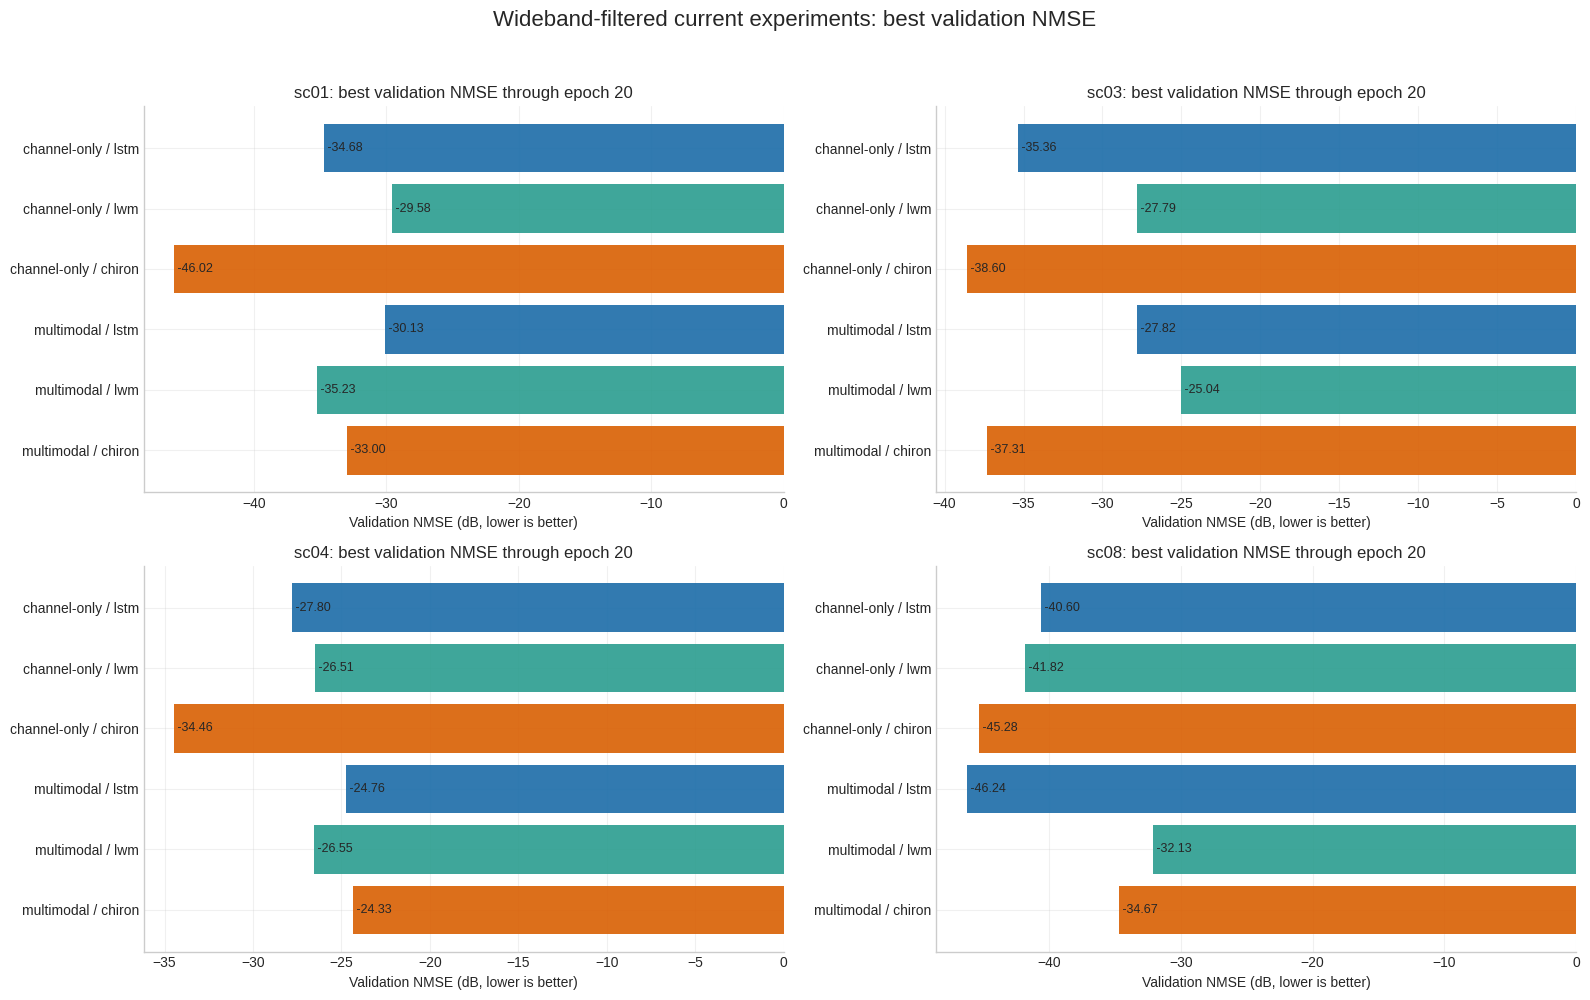

In [5]:
MODEL_COLORS = {
    'lstm': '#1b6ca8',
    'lwm': '#2a9d8f',
    'lwm_temporal': '#8a5cf6',
    'chiron': '#d95f02',
}
MODE_LABELS = {'channel_only': 'channel-only', 'multimodal': 'multimodal', 'image_only': 'image-only'}
MODE_MARKERS = {'channel_only': 'o', 'multimodal': 's', 'image_only': '^'}
mode_order_map = {m: i for i, m in enumerate(MODE_ORDER)}
model_order_map = {m: i for i, m in enumerate(MODEL_ORDER)}

def ordered_values(values, order):
    values = list(values)
    return [x for x in order if x in values] + sorted([x for x in values if x not in order])

def sorted_runs(df):
    out = df.copy()
    out['mode_order'] = out['mode'].map(mode_order_map).fillna(99)
    out['model_order'] = out['model'].map(model_order_map).fillna(99)
    return out.sort_values(['scenario', 'mode_order', 'model_order'])

def label_for(row):
    return f"{MODE_LABELS.get(row['mode'], row['mode'])} / {row['model']}"

def style_axis(ax):
    ax.grid(True, alpha=0.28)
    ax.spines[['top', 'right']].set_visible(False)

scenarios = ordered_values(canonical['scenario'].dropna().unique(), ['sc01', 'sc03', 'sc04', 'sc08'])

fig, axes = plt.subplots(2, 2, figsize=(16, 10), squeeze=False)
for ax, scenario in zip(axes.ravel(), scenarios):
    sub = sorted_runs(canonical[canonical['scenario'].eq(scenario)])
    labels = [label_for(row) for _, row in sub.iterrows()]
    colors = [MODEL_COLORS.get(row['model'], '#777777') for _, row in sub.iterrows()]
    bars = ax.barh(labels, sub['best_val_nmse_db'], color=colors, alpha=0.9)
    ax.set_title(f'{scenario}: best validation NMSE through epoch {EPOCH_LIMIT}')
    ax.set_xlabel('Validation NMSE (dB, lower is better)')
    ax.invert_yaxis()
    style_axis(ax)
    for bar, value in zip(bars, sub['best_val_nmse_db']):
        ax.text(value, bar.get_y() + bar.get_height() / 2, f' {value:.2f}', va='center', fontsize=9)
for ax in axes.ravel()[len(scenarios):]:
    ax.axis('off')
fig.suptitle('Wideband-filtered current experiments: best validation NMSE', fontsize=16, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## Validation Curves Over Epoch

x-axis: epoch. y-axis: validation metric.

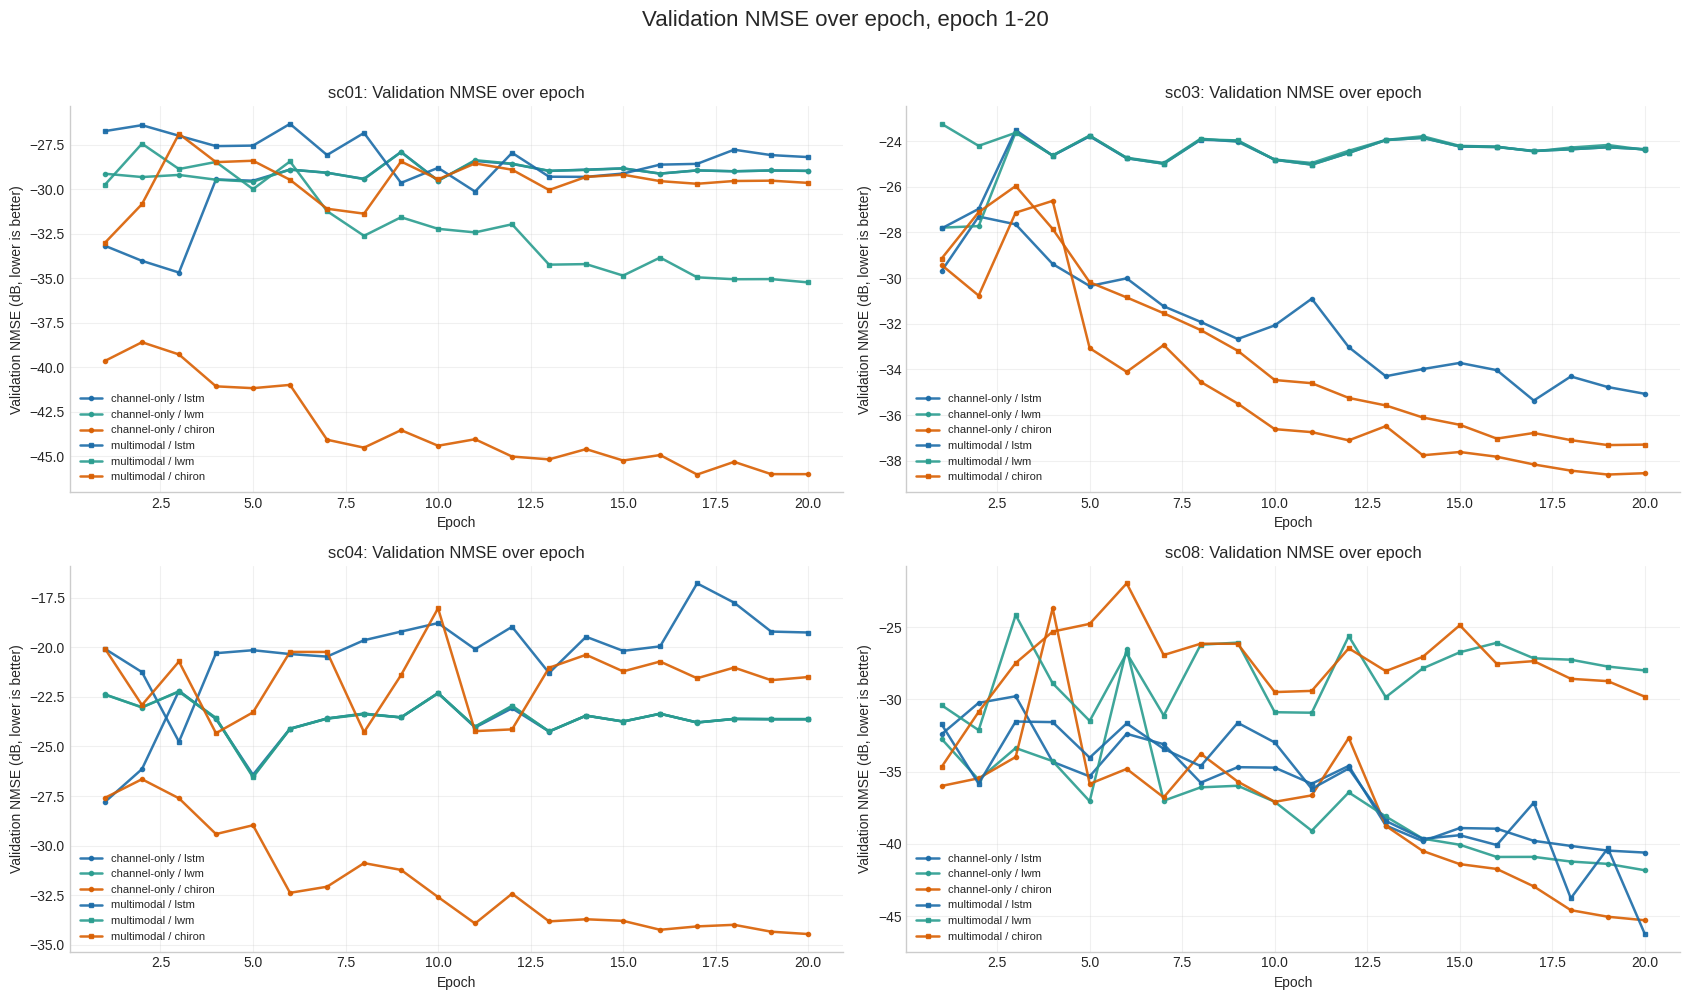

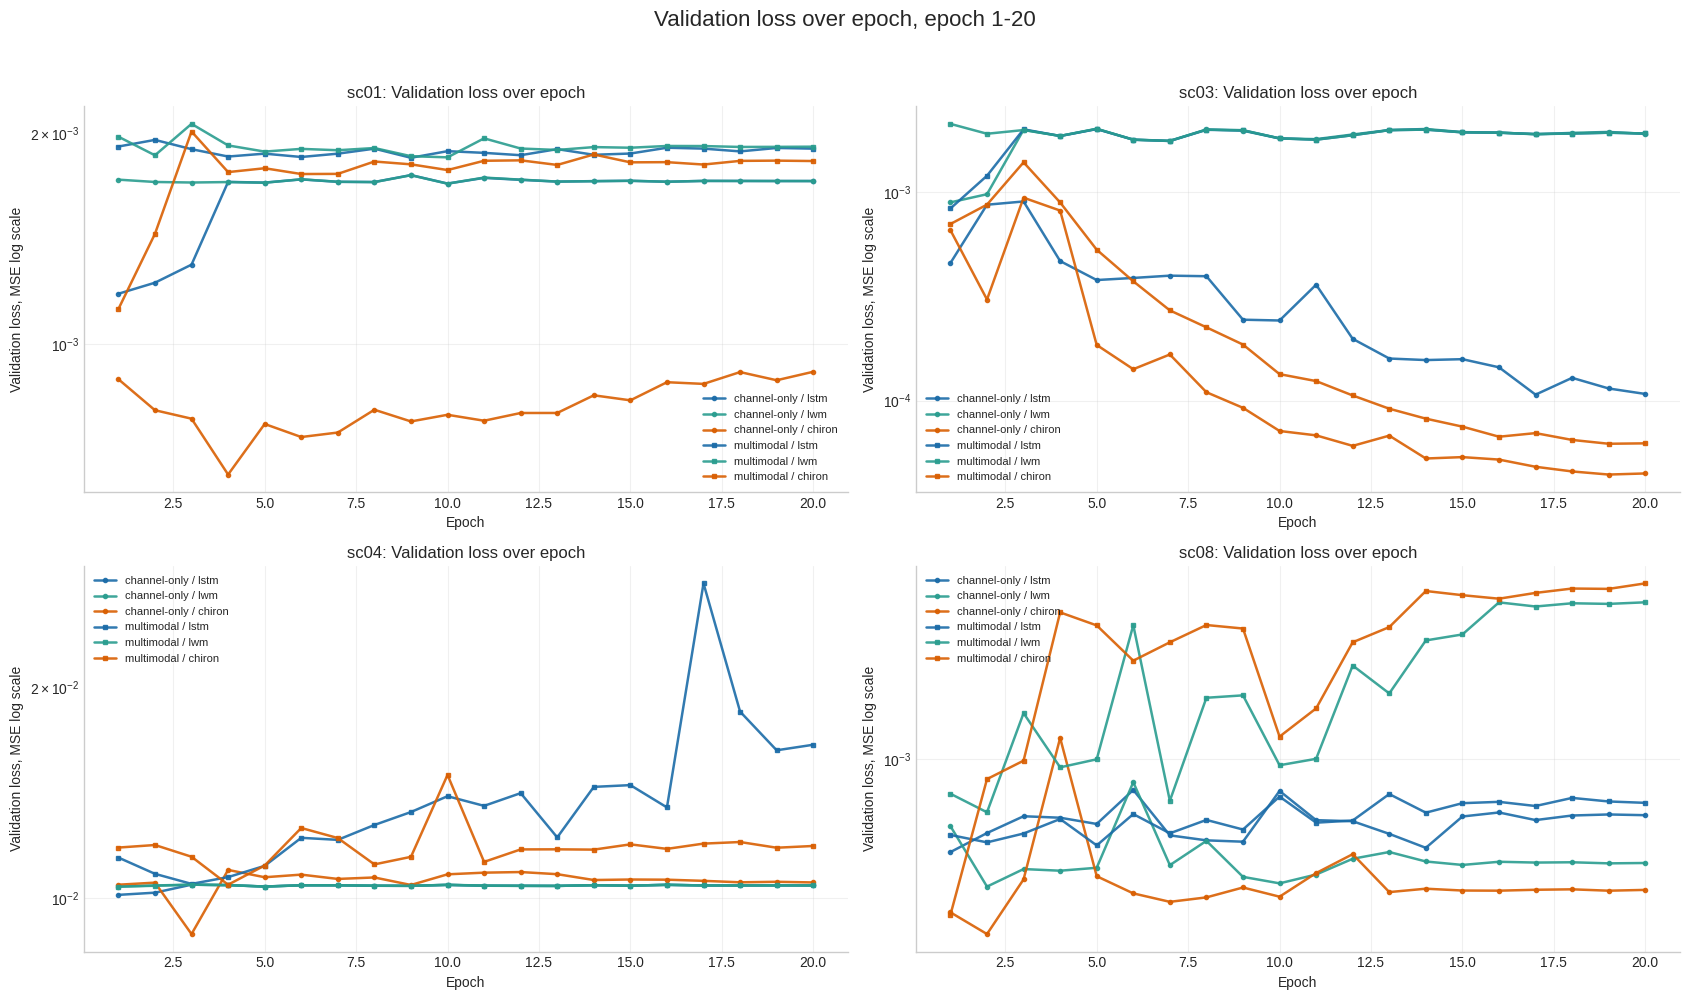

In [6]:
canonical_run_ids = set(canonical['run_id'])
plot_history = limited[limited['run_id'].isin(canonical_run_ids)].copy()

for metric, ylabel, title, use_log in [
    ('val_nmse_db', 'Validation NMSE (dB, lower is better)', 'Validation NMSE over epoch', False),
    ('val_loss', 'Validation loss, MSE log scale', 'Validation loss over epoch', True),
]:
    fig, axes = plt.subplots(2, 2, figsize=(17, 10), squeeze=False)
    for ax, scenario in zip(axes.ravel(), scenarios):
        sub_summary = sorted_runs(canonical[canonical['scenario'].eq(scenario)])
        for _, row in sub_summary.iterrows():
            run = plot_history[plot_history['run_id'].eq(row['run_id'])].sort_values('epoch')
            ax.plot(
                run['epoch'], run[metric],
                label=label_for(row),
                color=MODEL_COLORS.get(row['model'], '#777777'),
                marker=MODE_MARKERS.get(row['mode'], 'o'),
                markersize=3,
                linewidth=1.8,
                alpha=0.9,
            )
        if use_log:
            ax.set_yscale('log')
        ax.set_title(f'{scenario}: {title}')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        style_axis(ax)
        ax.legend(fontsize=8)
    for ax in axes.ravel()[len(scenarios):]:
        ax.axis('off')
    fig.suptitle(f'{title}, epoch 1-{EPOCH_LIMIT}', fontsize=16, y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

## Train vs Validation Curves

Solid lines are validation metrics. Dashed lines are training metrics.

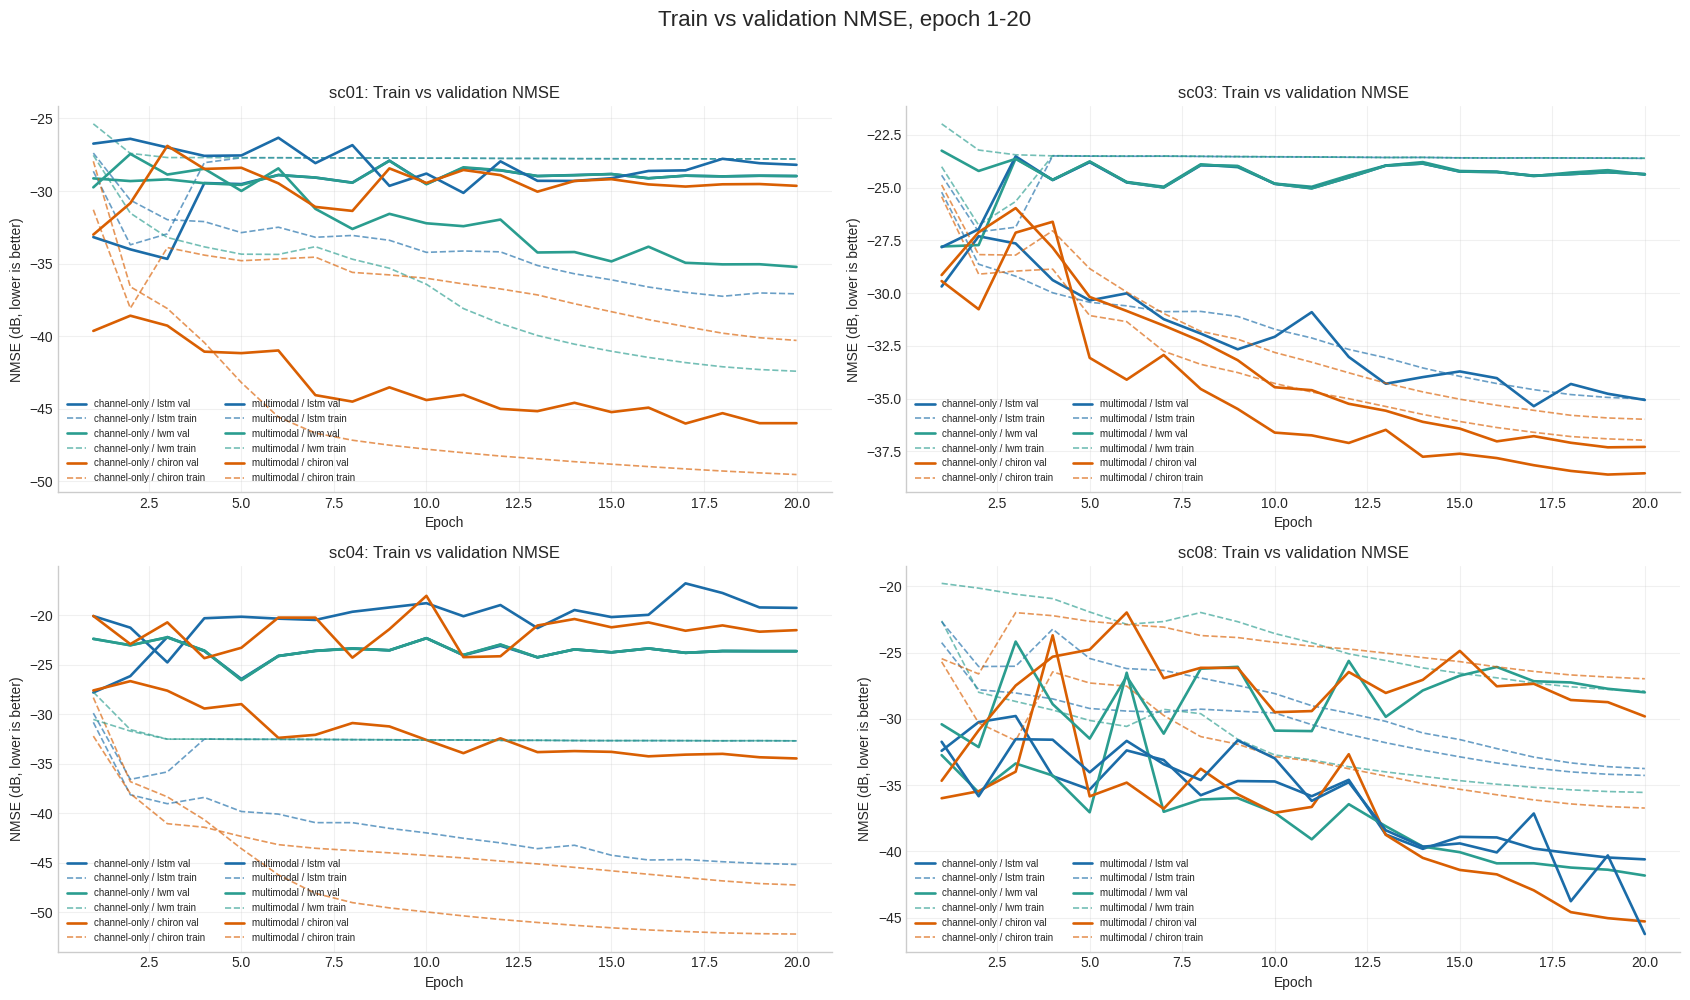

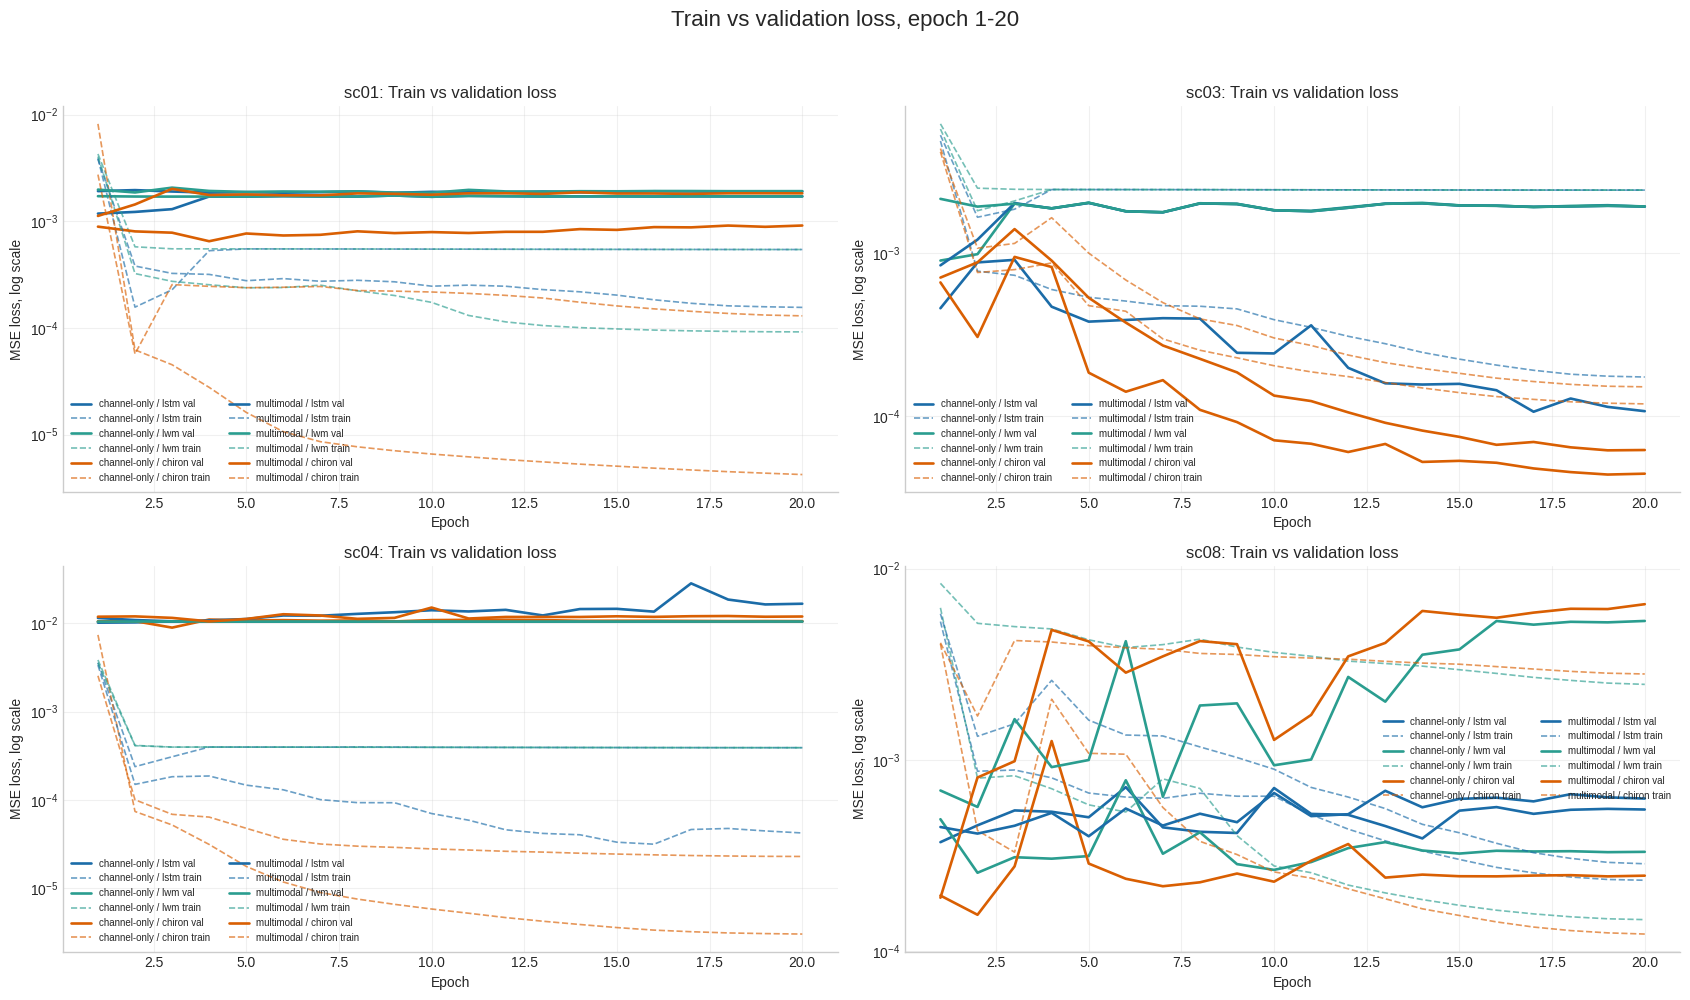

In [7]:
for metric_pair, ylabel, title, use_log in [
    (('train_nmse_db', 'val_nmse_db'), 'NMSE (dB, lower is better)', 'Train vs validation NMSE', False),
    (('train_loss', 'val_loss'), 'MSE loss, log scale', 'Train vs validation loss', True),
]:
    train_metric, val_metric = metric_pair
    fig, axes = plt.subplots(2, 2, figsize=(17, 10), squeeze=False)
    for ax, scenario in zip(axes.ravel(), scenarios):
        sub_summary = sorted_runs(canonical[canonical['scenario'].eq(scenario)])
        for _, row in sub_summary.iterrows():
            run = plot_history[plot_history['run_id'].eq(row['run_id'])].sort_values('epoch')
            color = MODEL_COLORS.get(row['model'], '#777777')
            ax.plot(run['epoch'], run[val_metric], color=color, linewidth=1.9, label=f"{label_for(row)} val")
            ax.plot(run['epoch'], run[train_metric], color=color, linewidth=1.2, linestyle='--', alpha=0.65, label=f"{label_for(row)} train")
        if use_log:
            ax.set_yscale('log')
        ax.set_title(f'{scenario}: {title}')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        style_axis(ax)
        ax.legend(fontsize=7, ncol=2)
    for ax in axes.ravel()[len(scenarios):]:
        ax.axis('off')
    fig.suptitle(f'{title}, epoch 1-{EPOCH_LIMIT}', fontsize=16, y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

## Train-Validation Gap

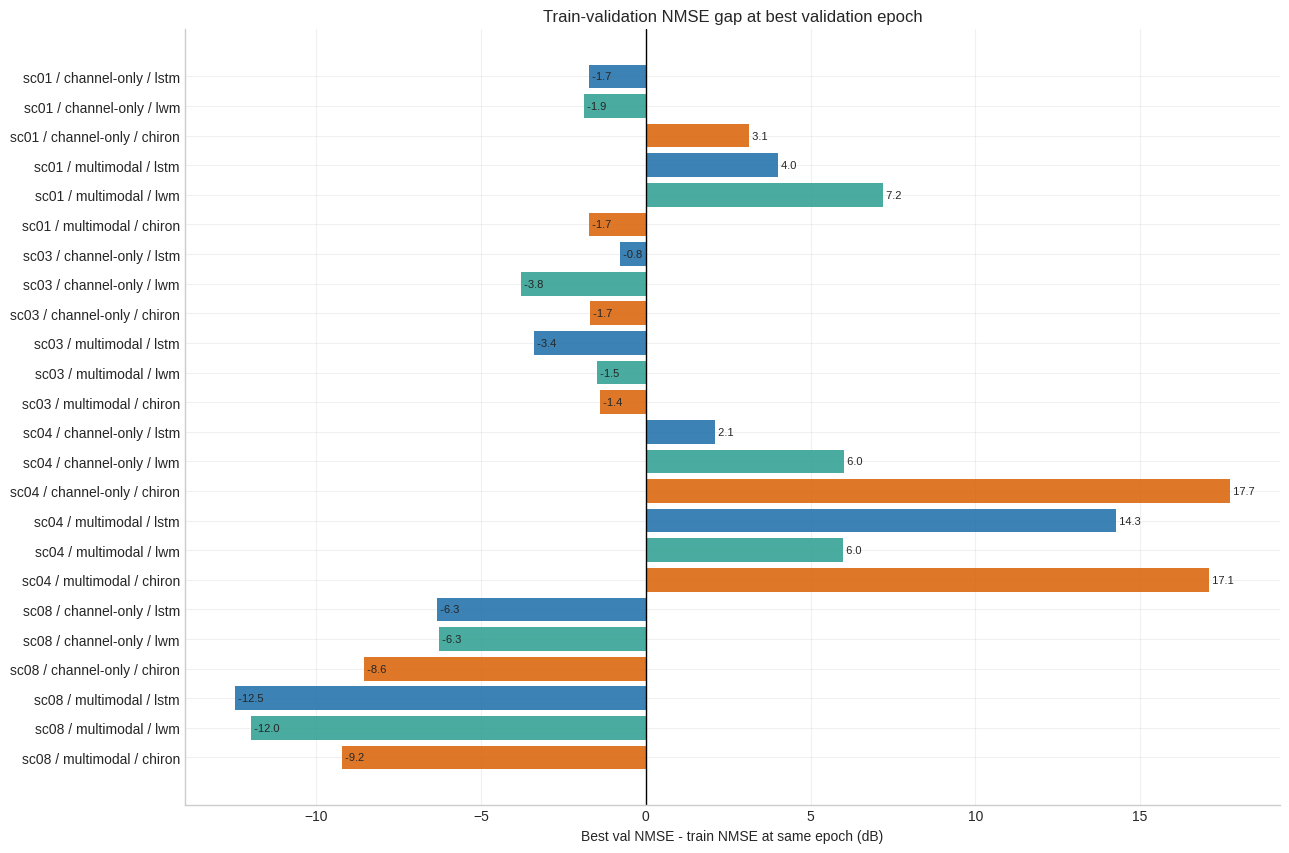

In [8]:
gap_df = sorted_runs(canonical).copy()
gap_df['label'] = gap_df['scenario'] + ' / ' + gap_df['mode'].map(MODE_LABELS).fillna(gap_df['mode']) + ' / ' + gap_df['model']

fig, ax = plt.subplots(figsize=(13, max(6, 0.36 * len(gap_df))))
colors = [MODEL_COLORS.get(model, '#777777') for model in gap_df['model']]
bars = ax.barh(gap_df['label'], gap_df['train_val_nmse_gap_db_at_best'], color=colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Train-validation NMSE gap at best validation epoch')
ax.set_xlabel('Best val NMSE - train NMSE at same epoch (dB)')
ax.invert_yaxis()
style_axis(ax)
for bar, value in zip(bars, gap_df['train_val_nmse_gap_db_at_best']):
    ax.text(value, bar.get_y() + bar.get_height() / 2, f' {value:.1f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

<!-- CURRENT_RESULTS_VISUALIZATION_V1 -->
## Current Results Visualization

This appended section summarizes the current disk state, excluding legacy per-subcarrier LSTM/LWM runs and the intentionally-excluded `lwm_temporal` model, and keeping the latest non-legacy run per `scenario/mode/model`. The figures below are generated in this notebook folder and can be regenerated by running the next two code cells.

Generated CSV files:

- `current_results_summary.csv`
- `current_epoch_history.csv`
- `current_pairwise_multimodal_gain.csv`
- `current_raw_space_eval.csv`
- `current_raw_best_vs_copy.csv`
- `current_scenario_leaderboard.csv`

### Generated Figures

![Current experiment coverage](current_coverage_heatmap.png)

![Current normalized best NMSE](current_normalized_best_nmse.png)

![Current multimodal gain/loss](current_multimodal_gain_loss.png)

![Current key training curves](current_key_training_curves.png)

![Current raw-space vs copy-last](current_raw_space_vs_copy_last.png)

![Current scenario leaderboard](current_scenario_leaderboard.png)


In [9]:
from pathlib import Path
import json
import re
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

EPOCH_LIMIT = 20
# lwm_temporal is intentionally excluded from this comparison.
MODEL_ORDER = ['lstm', 'lwm', 'chiron']
EXCLUDE_MODELS = {'lwm_temporal'}
_DETECT_MODELS = ['lstm', 'lwm', 'lwm_temporal', 'chiron']
MODE_ORDER = ['channel_only', 'multimodal']
SCENARIO_ORDER = ['sc01', 'sc03', 'sc04', 'sc08']
MODEL_COLORS = {'lstm': '#1b6ca8', 'lwm': '#2a9d8f', 'lwm_temporal': '#8a5cf6', 'chiron': '#d95f02', 'copy_last': '#444444'}
MODE_LABEL = {'channel_only': 'channel-only', 'multimodal': 'multimodal'}

NOTEBOOK_DIR = Path.cwd().resolve()
repo_root = None
for candidate in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents]:
    if (candidate / 'multimodal_code_index/run_multimodal_16to4').exists():
        repo_root = candidate
        break
if repo_root is None:
    raise RuntimeError('Could not find repository root.')
RUN_ROOT = repo_root / 'multimodal_code_index/run_multimodal_16to4/outputs'
CHECKPOINT_DIR = RUN_ROOT / 'checkpoints'
RAW_EVAL_PATH = RUN_ROOT / 'raw_space_eval.json'
FIGURE_DIR = RUN_ROOT / 'figures/all_experiments_overview'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

def infer_scenario(path, args):
    scenarios = args.get('scenarios') or []
    if isinstance(scenarios, list) and scenarios:
        return str(scenarios[0]).lower()
    match = re.search(r'sc\d+', path.name, re.IGNORECASE)
    return match.group(0).lower() if match else 'unknown'

def infer_mode(path, args):
    if args.get('mode'):
        return str(args['mode'])
    if 'channel_only' in path.name:
        return 'channel_only'
    if 'multimodal' in path.name:
        return 'multimodal'
    return 'unknown'

def infer_model(path, data, args):
    if args.get('model'):
        return str(args['model'])
    if data.get('model_name'):
        return str(data['model_name'])
    for model in _DETECT_MODELS:
        if model in path.name:
            return model
    return 'unknown'

def is_legacy_lstm_lwm(path, model):
    if model not in {'lstm', 'lwm'}:
        return False
    name = path.name
    return name.startswith('multimodal4_channel_only_') or (name.startswith('multimodal4_multimodal_') and 'sc01030408' not in name)

def load_current_results():
    rows, metadata = [], []
    for path in sorted(CHECKPOINT_DIR.glob('*_history.json')):
        data = json.loads(path.read_text())
        args = data.get('args') or {}
        hist = data.get('history') or []
        if not hist:
            continue
        scenario = infer_scenario(path, args)
        mode = infer_mode(path, args)
        model = infer_model(path, data, args)
        if model in EXCLUDE_MODELS:
            continue
        legacy = is_legacy_lstm_lwm(path, model)
        run_id = path.stem.replace('_history', '')
        metadata.append({'run_id': run_id, 'source_file': path.name, 'scenario': scenario, 'mode': mode, 'model': model, 'legacy_excluded': legacy, 'num_parameters': data.get('num_parameters'), 'epochs_in_file': len(hist), 'mtime': path.stat().st_mtime, 'lr': args.get('lr'), 'amp': args.get('amp'), 'batch_size': args.get('batch_size'), 'device': args.get('device')})
        if legacy:
            continue
        elapsed = 0.0
        for item in hist:
            epoch = item.get('epoch')
            if not isinstance(epoch, int) or epoch > EPOCH_LIMIT:
                continue
            elapsed += float(item.get('time_s') or 0.0)
            train, val = item.get('train') or {}, item.get('val') or {}
            rows.append({'run_id': run_id, 'source_file': path.name, 'scenario': scenario, 'mode': mode, 'model': model, 'epoch': epoch, 'time_hours': elapsed / 3600.0, 'train_loss': train.get('loss'), 'val_loss': val.get('loss'), 'train_nmse_db': train.get('nmse_db'), 'val_nmse_db': val.get('nmse_db'), 'train_cosine_sim': train.get('cosine_sim'), 'val_cosine_sim': val.get('cosine_sim'), 'num_parameters': data.get('num_parameters'), 'mtime': path.stat().st_mtime, 'lr': args.get('lr'), 'amp': args.get('amp'), 'batch_size': args.get('batch_size'), 'device': args.get('device')})
    history = pd.DataFrame(rows)
    meta = pd.DataFrame(metadata)
    if history.empty:
        raise RuntimeError('No current non-legacy history rows found.')
    best_idx = history.groupby('run_id')['val_nmse_db'].idxmin()
    best = history.loc[best_idx].copy().rename(columns={'epoch': 'best_epoch', 'val_nmse_db': 'best_val_nmse_db', 'val_loss': 'best_val_loss', 'val_cosine_sim': 'best_val_cosine_sim', 'train_nmse_db': 'train_nmse_db_at_best', 'train_loss': 'train_loss_at_best'})
    final_idx = history.groupby('run_id')['epoch'].idxmax()
    final = history.loc[final_idx, ['run_id', 'epoch', 'val_nmse_db', 'val_loss', 'train_nmse_db']].rename(columns={'epoch': 'final_epoch', 'val_nmse_db': 'final_val_nmse_db', 'val_loss': 'final_val_loss', 'train_nmse_db': 'final_train_nmse_db'})
    summary = best.merge(final, on='run_id', how='left')
    summary['train_val_nmse_gap_db_at_best'] = summary['best_val_nmse_db'] - summary['train_nmse_db_at_best']
    summary = summary.sort_values(['scenario', 'mode', 'model', 'mtime']).drop_duplicates(['scenario', 'mode', 'model'], keep='last').sort_values(['scenario', 'mode', 'model']).reset_index(drop=True)
    history = history[history['run_id'].isin(set(summary['run_id']))].copy()
    return summary, history, meta

summary, history, meta = load_current_results()
raw_df = pd.DataFrame(json.loads(RAW_EVAL_PATH.read_text())) if RAW_EVAL_PATH.exists() else pd.DataFrame()
if not raw_df.empty and 'model' in raw_df.columns:
    raw_df = raw_df[~raw_df['model'].isin(EXCLUDE_MODELS)].copy()
summary.to_csv(FIGURE_DIR / 'current_results_summary.csv', index=False)
history.to_csv(FIGURE_DIR / 'current_epoch_history.csv', index=False)
meta.sort_values(['legacy_excluded', 'scenario', 'mode', 'model', 'mtime']).to_csv(FIGURE_DIR / 'current_run_metadata.csv', index=False)
if not raw_df.empty:
    raw_df.to_csv(FIGURE_DIR / 'current_raw_space_eval.csv', index=False)

display(Markdown(f'Loaded **{len(summary)}** current scenario/mode/model results (lwm_temporal excluded by design). Legacy per-subcarrier LSTM/LWM files excluded: **{int(meta["legacy_excluded"].sum())}**.'))
display(summary[['scenario', 'mode', 'model', 'best_epoch', 'best_val_nmse_db', 'final_epoch', 'final_val_nmse_db', 'source_file']].style.format({'best_val_nmse_db': '{:.3f}', 'final_val_nmse_db': '{:.3f}'}))

Loaded **24** current scenario/mode/model results (lwm_temporal excluded by design). Legacy per-subcarrier LSTM/LWM files excluded: **8**.

,scenario,mode,model,best_epoch,best_val_nmse_db,final_epoch,final_val_nmse_db,source_file
0,sc01,channel_only,chiron,17,-46.018,20,-45.995,multimodal4_channel_only_sc01_K16_P4_img8_chiron_history.json
1,sc01,channel_only,lstm,3,-34.676,20,-28.968,post_lstm_lwm_wideband_amp_epochs20_20260529_233331_channel_only_lstm_history.json
2,sc01,channel_only,lwm,5,-29.577,20,-28.968,post_lstm_lwm_wideband_amp_epochs20_20260529_233331_channel_only_lwm_history.json
3,sc01,multimodal,chiron,1,-33.004,20,-29.643,multimodal4_sc01030408_lr1e3_noamp_20260606_124953_sc01_multimodal_chiron_history.json
4,sc01,multimodal,lstm,11,-30.128,20,-28.194,multimodal4_sc01030408_lr1e3_noamp_20260606_124953_sc01_multimodal_lstm_history.json
5,sc01,multimodal,lwm,20,-35.230,20,-35.230,multimodal4_sc01030408_lr1e3_noamp_20260606_124953_sc01_multimodal_lwm_history.json
6,sc03,channel_only,chiron,19,-38.598,20,-38.539,channel_only_temporal_chiron_noamp_20260603_162358_sc03_channel_only_chiron_history.json
7,sc03,channel_only,lstm,17,-35.359,20,-35.064,channel_only_sc08_sc03_amp_20260601_165600_sc03_channel_only_lstm_history.json
8,sc03,channel_only,lwm,1,-27.792,20,-24.386,channel_only_sc08_sc03_amp_20260601_165600_sc03_channel_only_lwm_history.json
9,sc03,multimodal,chiron,19,-37.308,20,-37.288,multimodal4_sc01030408_lr1e3_noamp_20260606_124953_sc03_multimodal_chiron_history.json


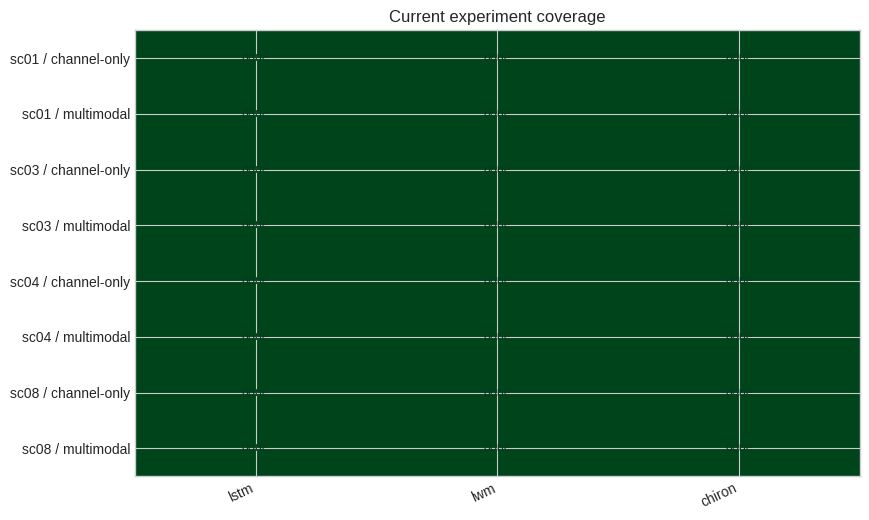

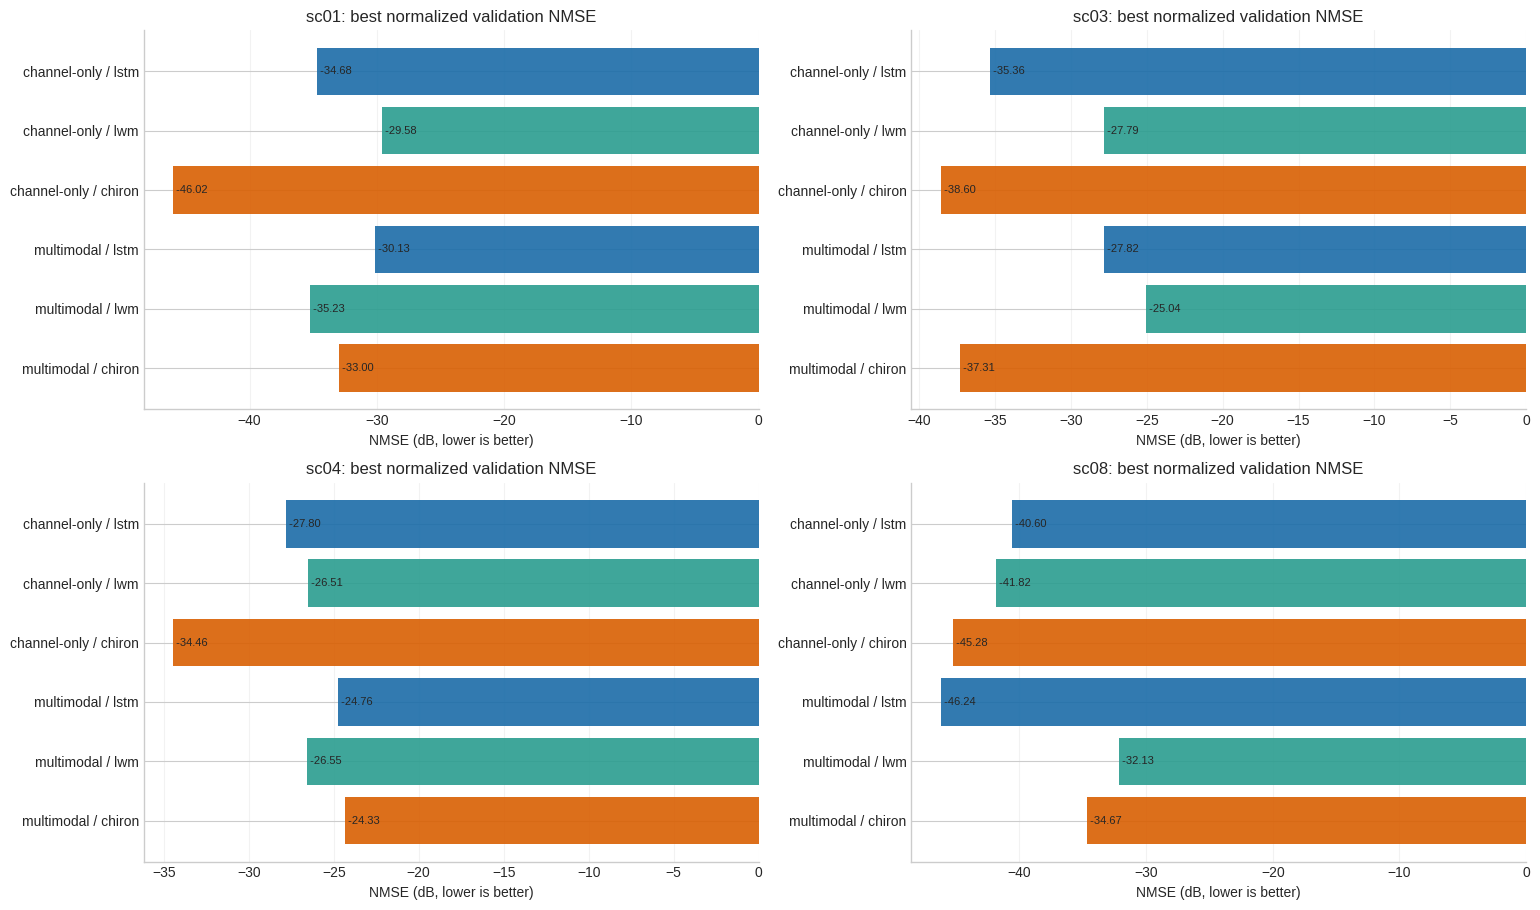

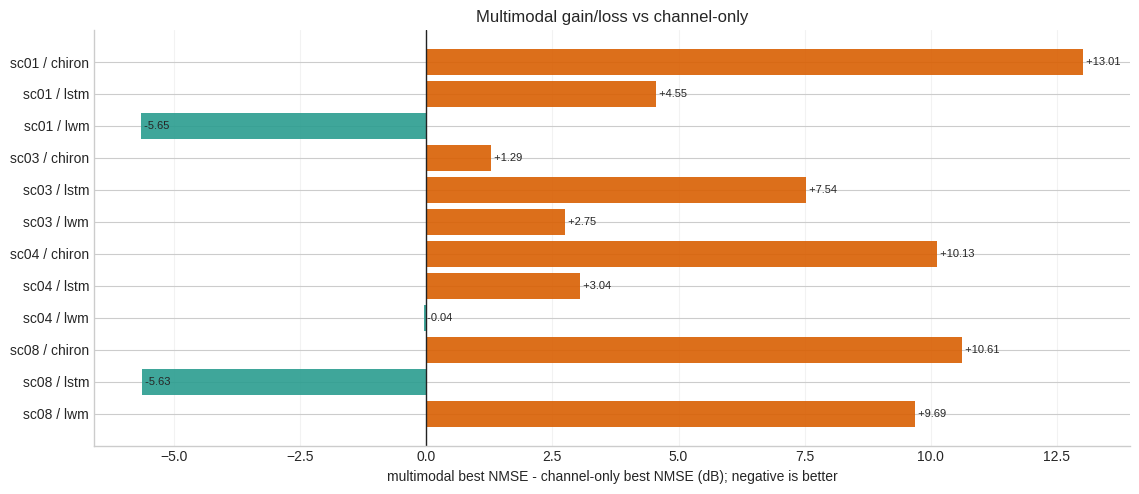

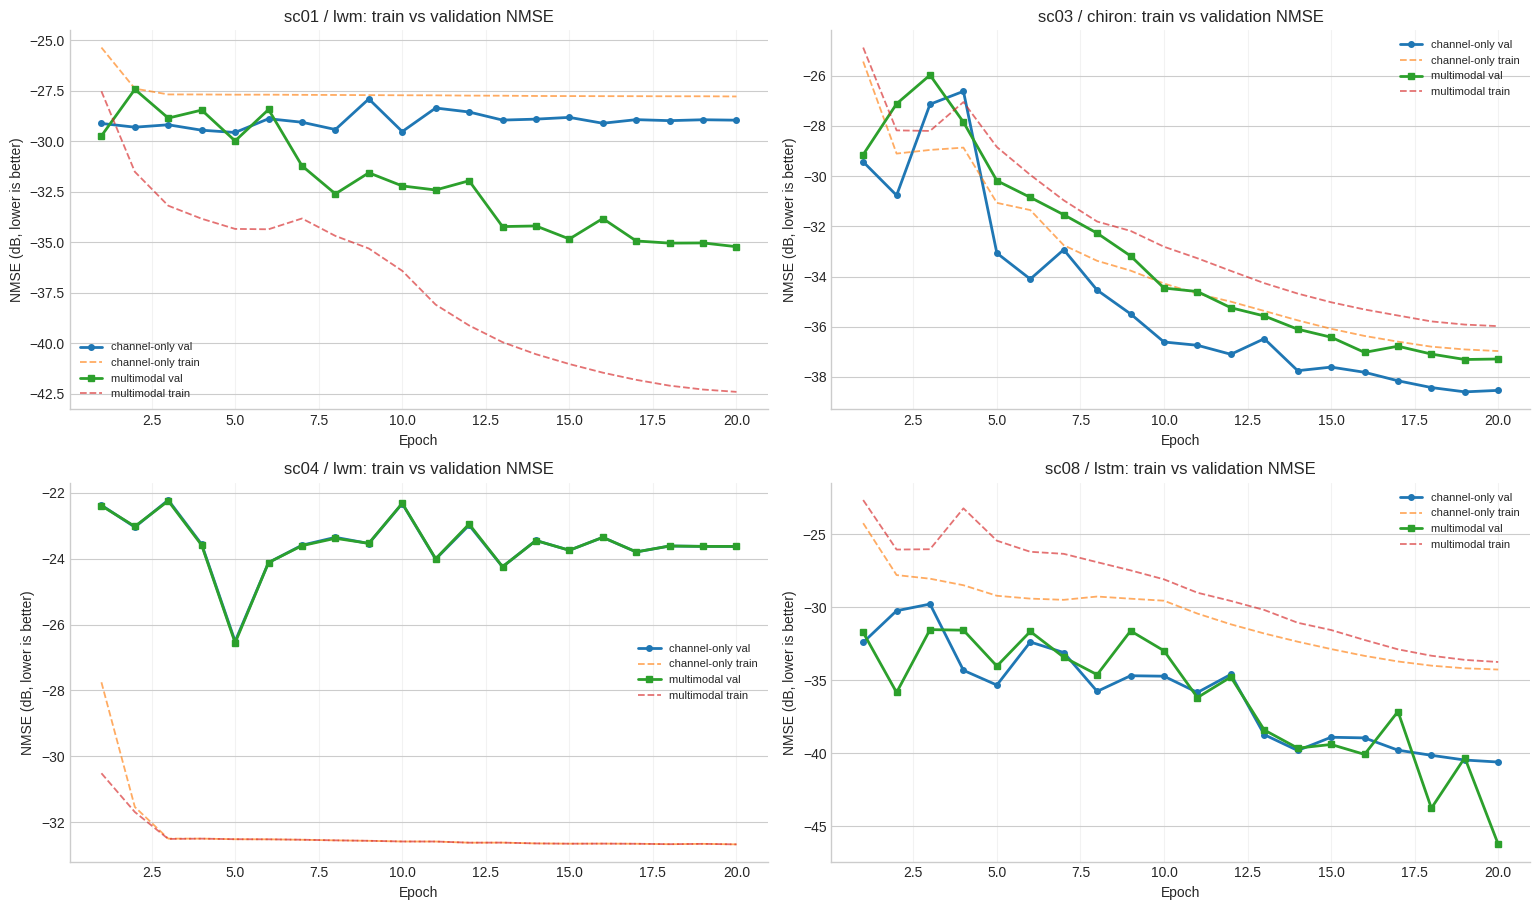

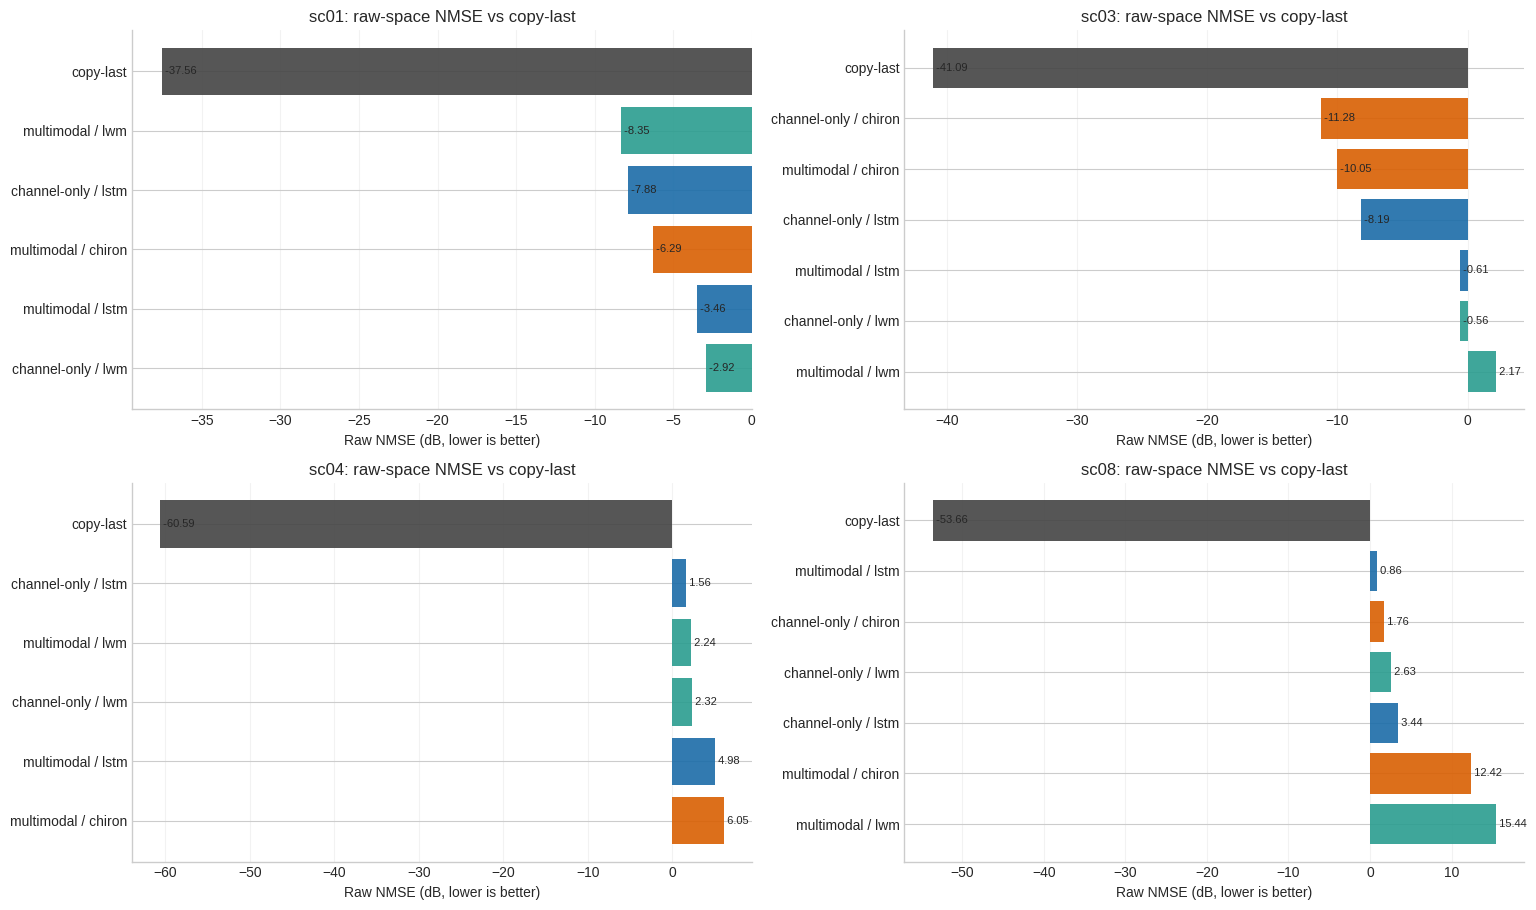

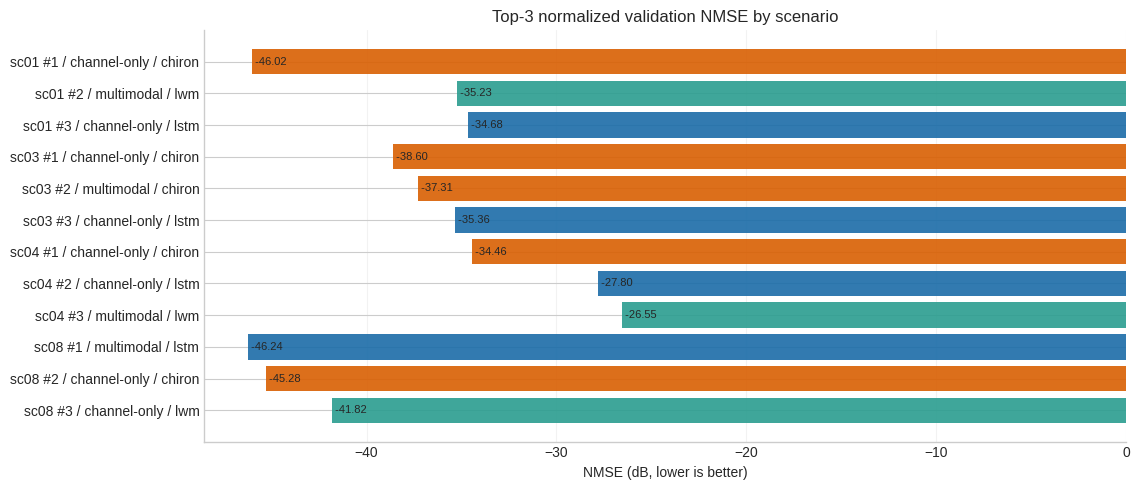

PosixPath('/mnt/ssd_7t_2/carla-wireless-dataset/multimodal_code_index/run_multimodal_16to4/outputs/figures/all_experiments_overview/current_scenario_leaderboard.png')

In [10]:
def sorted_summary(df):
    out = df.copy()
    out['scenario_order'] = out['scenario'].map({v: i for i, v in enumerate(SCENARIO_ORDER)}).fillna(99)
    out['mode_order'] = out['mode'].map({v: i for i, v in enumerate(MODE_ORDER)}).fillna(99)
    out['model_order'] = out['model'].map({v: i for i, v in enumerate(MODEL_ORDER)}).fillna(99)
    return out.sort_values(['scenario_order', 'mode_order', 'model_order'])

def style_axis(ax):
    ax.grid(True, alpha=0.25, axis='x')
    ax.spines[['top', 'right']].set_visible(False)

def savefig(name):
    path = FIGURE_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches='tight')
    plt.show()
    return path

coverage = summary.assign(available=1).pivot_table(index=['scenario', 'mode'], columns='model', values='available', aggfunc='max', fill_value=0).reindex(columns=MODEL_ORDER, fill_value=0)
coverage = coverage.reindex(pd.MultiIndex.from_product([SCENARIO_ORDER, MODE_ORDER], names=['scenario', 'mode']), fill_value=0)
fig, ax = plt.subplots(figsize=(8.8, 5.3))
ax.imshow(coverage.values, cmap='Greens', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(coverage.columns)), coverage.columns, rotation=25, ha='right')
ax.set_yticks(range(len(coverage.index)), [f'{sc} / {MODE_LABEL.get(mode, mode)}' for sc, mode in coverage.index])
for y in range(coverage.shape[0]):
    for x in range(coverage.shape[1]):
        ax.text(x, y, 'done' if coverage.iat[y, x] else '-', ha='center', va='center', fontsize=9, color='#083b1d' if coverage.iat[y, x] else '#777777')
ax.set_title('Current experiment coverage')
savefig('current_coverage_heatmap.png')

fig, axes = plt.subplots(2, 2, figsize=(15.5, 9.2), squeeze=False)
for ax, scenario in zip(axes.ravel(), SCENARIO_ORDER):
    sub = sorted_summary(summary[summary['scenario'].eq(scenario)])
    labels = [f"{MODE_LABEL.get(r.mode, r.mode)} / {r.model}" for r in sub.itertuples()]
    colors = [MODEL_COLORS.get(r.model, '#777777') for r in sub.itertuples()]
    bars = ax.barh(labels, sub['best_val_nmse_db'], color=colors, alpha=0.9)
    ax.invert_yaxis()
    ax.set_title(f'{scenario}: best normalized validation NMSE')
    ax.set_xlabel('NMSE (dB, lower is better)')
    style_axis(ax)
    for bar, value in zip(bars, sub['best_val_nmse_db']):
        ax.text(value, bar.get_y() + bar.get_height() / 2, f' {value:.2f}', va='center', fontsize=8)
savefig('current_normalized_best_nmse.png')

pairs = []
for scenario in SCENARIO_ORDER:
    for model in MODEL_ORDER:
        co = summary[(summary['scenario'].eq(scenario)) & (summary['mode'].eq('channel_only')) & (summary['model'].eq(model))]
        mm = summary[(summary['scenario'].eq(scenario)) & (summary['mode'].eq('multimodal')) & (summary['model'].eq(model))]
        if not co.empty and not mm.empty:
            pairs.append({'scenario': scenario, 'model': model, 'channel_only_nmse': float(co.iloc[0]['best_val_nmse_db']), 'multimodal_nmse': float(mm.iloc[0]['best_val_nmse_db']), 'gain_db': float(mm.iloc[0]['best_val_nmse_db'] - co.iloc[0]['best_val_nmse_db'])})
pair_df = pd.DataFrame(pairs)
pair_df.to_csv(FIGURE_DIR / 'current_pairwise_multimodal_gain.csv', index=False)
if not pair_df.empty:
    pair_df['label'] = pair_df['scenario'] + ' / ' + pair_df['model']
    pair_df = pair_df.sort_values(['scenario', 'model'])
    fig, ax = plt.subplots(figsize=(11.5, max(4.5, 0.42 * len(pair_df))))
    colors = ['#2a9d8f' if v < 0 else '#d95f02' for v in pair_df['gain_db']]
    bars = ax.barh(pair_df['label'], pair_df['gain_db'], color=colors, alpha=0.9)
    ax.axvline(0, color='#222222', linewidth=1)
    ax.invert_yaxis()
    ax.set_title('Multimodal gain/loss vs channel-only')
    ax.set_xlabel('multimodal best NMSE - channel-only best NMSE (dB); negative is better')
    style_axis(ax)
    for bar, value in zip(bars, pair_df['gain_db']):
        ax.text(value, bar.get_y() + bar.get_height() / 2, f' {value:+.2f}', va='center', fontsize=8)
    savefig('current_multimodal_gain_loss.png')

key_pairs = [('sc01', 'lwm'), ('sc03', 'chiron'), ('sc04', 'lwm'), ('sc08', 'lstm')]
fig, axes = plt.subplots(2, 2, figsize=(15.5, 9.2), squeeze=False)
for ax, (scenario, model) in zip(axes.ravel(), key_pairs):
    for mode, marker in [('channel_only', 'o'), ('multimodal', 's')]:
        run = summary[(summary['scenario'].eq(scenario)) & (summary['mode'].eq(mode)) & (summary['model'].eq(model))]
        if run.empty:
            continue
        cur = history[history['run_id'].eq(run.iloc[0]['run_id'])].sort_values('epoch')
        ax.plot(cur['epoch'], cur['val_nmse_db'], marker=marker, linewidth=2, markersize=4, label=f'{MODE_LABEL[mode]} val')
        ax.plot(cur['epoch'], cur['train_nmse_db'], linestyle='--', linewidth=1.3, alpha=0.65, label=f'{MODE_LABEL[mode]} train')
    ax.set_title(f'{scenario} / {model}: train vs validation NMSE')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('NMSE (dB, lower is better)')
    style_axis(ax)
    ax.legend(fontsize=8)
savefig('current_key_training_curves.png')

if not raw_df.empty:
    raw_df.sort_values('raw_nmse').groupby('sc', as_index=False).first().to_csv(FIGURE_DIR / 'current_raw_best_vs_copy.csv', index=False)
    fig, axes = plt.subplots(2, 2, figsize=(15.5, 9.2), squeeze=False)
    for ax, scenario in zip(axes.ravel(), SCENARIO_ORDER):
        sub = raw_df[raw_df['sc'].eq(scenario)].copy()
        if sub.empty:
            ax.axis('off')
            continue
        sub['label'] = sub['mode'].map(MODE_LABEL).fillna(sub['mode']) + ' / ' + sub['model']
        sub = sub.sort_values('raw_nmse')
        labels = ['copy-last'] + sub['label'].tolist()
        values = [float(sub.iloc[0]['raw_copy_last'])] + sub['raw_nmse'].astype(float).tolist()
        colors = [MODEL_COLORS['copy_last']] + [MODEL_COLORS.get(m, '#777777') for m in sub['model']]
        bars = ax.barh(labels, values, color=colors, alpha=0.9)
        ax.invert_yaxis()
        ax.set_title(f'{scenario}: raw-space NMSE vs copy-last')
        ax.set_xlabel('Raw NMSE (dB, lower is better)')
        style_axis(ax)
        for bar, value in zip(bars, values):
            ax.text(value, bar.get_y() + bar.get_height() / 2, f' {value:.2f}', va='center', fontsize=8)
    savefig('current_raw_space_vs_copy_last.png')

leader_rows = []
for scenario in SCENARIO_ORDER:
    sub = sorted_summary(summary[summary['scenario'].eq(scenario)]).sort_values('best_val_nmse_db').head(3)
    for rank, (_, row) in enumerate(sub.iterrows(), start=1):
        leader_rows.append({'scenario': scenario, 'rank': rank, 'mode': row['mode'], 'model': row['model'], 'best_epoch': row['best_epoch'], 'best_val_nmse_db': row['best_val_nmse_db']})
leader_df = pd.DataFrame(leader_rows)
leader_df.to_csv(FIGURE_DIR / 'current_scenario_leaderboard.csv', index=False)
fig, ax = plt.subplots(figsize=(11.5, max(5.0, 0.36 * len(leader_df))))
leader_df['label'] = leader_df['scenario'] + ' #' + leader_df['rank'].astype(str) + ' / ' + leader_df['mode'].map(MODE_LABEL).fillna(leader_df['mode']) + ' / ' + leader_df['model']
colors = [MODEL_COLORS.get(m, '#777777') for m in leader_df['model']]
bars = ax.barh(leader_df['label'], leader_df['best_val_nmse_db'], color=colors, alpha=0.9)
ax.invert_yaxis()
ax.set_title('Top-3 normalized validation NMSE by scenario')
ax.set_xlabel('NMSE (dB, lower is better)')
style_axis(ax)
for bar, value in zip(bars, leader_df['best_val_nmse_db']):
    ax.text(value, bar.get_y() + bar.get_height() / 2, f' {value:.2f}', va='center', fontsize=8)
savefig('current_scenario_leaderboard.png')

<!-- ACTUAL_VS_PREDICTED_FROM_CHECKPOINTS_V1 -->

## Actual vs Predicted From Reloaded Checkpoints

These figures were generated by reloading all current checkpoints listed in `current_results_summary.csv`, excluding `lwm_temporal`, running the validation split, denormalizing predictions and targets back to raw channel space, and plotting actual values against predicted values. The scatter plot flattens real and imaginary channel components; the profile plots compare `Re(H)` and `Im(H)` over subcarriers for one validation sample.


In [ ]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

if 'CONSOLIDATED_DIR' in globals():
    actual_pred_dir = CONSOLIDATED_DIR / 'actual_vs_predicted'
elif 'FIGURE_DIR' in globals():
    actual_pred_dir = Path(FIGURE_DIR) / 'actual_vs_predicted'
else:
    actual_pred_dir = Path.cwd() / 'actual_vs_predicted'

summary_path = actual_pred_dir / 'actual_vs_predicted_summary.csv'
display(Markdown(f'Generated files: `{actual_pred_dir}`'))
display(pd.read_csv(summary_path)[[
    'scenario', 'mode', 'model', 'split', 'num_samples',
    'raw_nmse_db_on_plotted_samples', 'best_val_nmse_db_from_training'
]])

display(Image(filename=str(actual_pred_dir / 'actual_vs_predicted_scatter.png')))
for image_path in sorted(actual_pred_dir.glob('component_profile_*.png')):
    display(Markdown(f'### {image_path.stem}'))
    display(Image(filename=str(image_path)))


In [ ]:
# Regenerate these figures from the shell with a torch-enabled environment, for example:
# /home/dlghdbs200/anaconda3/envs/hoyun_312/bin/python \
#   /mnt/ssd_7t_2/carla-wireless-dataset/multimodal_code_index/run_multimodal_16to4/plot_actual_vs_predicted.py \
#   --selection all --max-samples 24 --batch-size 4 --device cuda:0


<!-- ACTUAL_VS_PREDICTED_SHARED_AXES_V1 -->

## Actual vs Predicted, Shared Raw Axes

This section is appended without changing the earlier actual-vs-predicted section. It reloads all current checkpoints from `current_results_summary.csv`, excludes `lwm_temporal`, and displays the separately generated shared-axis figures. The same raw-axis limits are used across runs so scenario scale differences in `Re(H)` and `Im(H)` remain visible.


In [ ]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

if 'CONSOLIDATED_DIR' in globals():
    shared_axes_dir = CONSOLIDATED_DIR / 'actual_vs_predicted_shared_axes'
elif 'FIGURE_DIR' in globals():
    shared_axes_dir = Path(FIGURE_DIR) / 'actual_vs_predicted_shared_axes'
else:
    shared_axes_dir = Path.cwd() / 'actual_vs_predicted_shared_axes'

summary_path = shared_axes_dir / 'actual_vs_predicted_summary.csv'
summary = pd.read_csv(summary_path)
display(Markdown(f'Generated files: `{shared_axes_dir}`'))
display(summary[[
    'scenario', 'mode', 'model', 'split', 'num_samples',
    'raw_nmse_db_on_plotted_samples',
    'shared_profile_ymin', 'shared_profile_ymax'
]])

display(Image(filename=str(shared_axes_dir / 'actual_vs_predicted_scatter.png')))
for image_path in sorted(shared_axes_dir.glob('component_profile_*.png')):
    display(Markdown(f'### {image_path.stem}'))
    display(Image(filename=str(image_path)))


In [ ]:
# Regenerate only the appended shared-axis figures from the shell with a torch-enabled environment:
# /home/dlghdbs200/anaconda3/envs/hoyun_312/bin/python \
#   /mnt/ssd_7t_2/carla-wireless-dataset/multimodal_code_index/run_multimodal_16to4/plot_actual_vs_predicted.py \
#   --selection all --max-samples 24 --batch-size 4 --device cuda:0 \
#   --output-dir /mnt/ssd_7t_2/carla-wireless-dataset/multimodal_code_index/run_multimodal_16to4/outputs/figures/all_experiments_overview/actual_vs_predicted_shared_axes


<!-- ACTUAL_VS_PREDICTED_NORMALIZED_SHARED_AXES_V1 -->

## Actual vs Predicted, Min-Max Normalized Space

This section is appended separately from the raw-space figures. It reloads all current checkpoints from `current_results_summary.csv`, excludes `lwm_temporal`, and compares predictions against targets before denormalization, using the min-max normalized channel tensors used during training. Axis limits are shared across runs.


In [ ]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

if 'CONSOLIDATED_DIR' in globals():
    normalized_axes_dir = CONSOLIDATED_DIR / 'actual_vs_predicted_normalized_shared_axes'
elif 'FIGURE_DIR' in globals():
    normalized_axes_dir = Path(FIGURE_DIR) / 'actual_vs_predicted_normalized_shared_axes'
else:
    normalized_axes_dir = Path.cwd() / 'actual_vs_predicted_normalized_shared_axes'

summary_path = normalized_axes_dir / 'actual_vs_predicted_summary.csv'
summary = pd.read_csv(summary_path)
display(Markdown(f'Generated files: `{normalized_axes_dir}`'))
display(summary[[
    'scenario', 'mode', 'model', 'split', 'value_space', 'num_samples',
    'normalized_nmse_db_on_plotted_samples',
    'shared_profile_ymin', 'shared_profile_ymax'
]])

display(Image(filename=str(normalized_axes_dir / 'actual_vs_predicted_scatter.png')))
for image_path in sorted(normalized_axes_dir.glob('component_profile_*.png')):
    display(Markdown(f'### {image_path.stem}'))
    display(Image(filename=str(image_path)))


In [ ]:
# Regenerate only the appended min-max-normalized figures from the shell:
# /home/dlghdbs200/anaconda3/envs/hoyun_312/bin/python \
#   /mnt/ssd_7t_2/carla-wireless-dataset/multimodal_code_index/run_multimodal_16to4/plot_actual_vs_predicted.py \
#   --selection all --space normalized --max-samples 24 --batch-size 4 --device cuda:0 \
#   --output-dir /mnt/ssd_7t_2/carla-wireless-dataset/multimodal_code_index/run_multimodal_16to4/outputs/figures/all_experiments_overview/actual_vs_predicted_normalized_shared_axes


<!-- ACTUAL_VS_PREDICTED_NORMALIZED_STEP1_SAMPLES_V1 -->

## Min-Max Normalized Step +1 Profiles Across Samples

This appended section shows multiple validation samples per run. Each figure uses min-max normalized values, future step `+1` only, antenna `0`, and plots `Re(H)` and `Im(H)` over subcarriers. Six evenly spaced samples are shown from the 24-sample subset used for the regression comparison.


In [ ]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

if 'CONSOLIDATED_DIR' in globals():
    step1_dir = CONSOLIDATED_DIR / 'actual_vs_predicted_normalized_step1_samples'
elif 'FIGURE_DIR' in globals():
    step1_dir = Path(FIGURE_DIR) / 'actual_vs_predicted_normalized_step1_samples'
else:
    step1_dir = Path.cwd() / 'actual_vs_predicted_normalized_step1_samples'

summary_path = step1_dir / 'actual_vs_predicted_summary.csv'
summary = pd.read_csv(summary_path)
display(Markdown(f'Generated files: `{step1_dir}`'))
display(summary[[
    'scenario', 'mode', 'model', 'value_space', 'num_samples',
    'normalized_nmse_db_on_plotted_samples',
    'shared_step1_ymin', 'shared_step1_ymax',
    'step1_samples_file'
]])

for image_path in sorted(step1_dir.glob('step1_samples_*.png')):
    display(Markdown(f'### {image_path.stem}'))
    display(Image(filename=str(image_path)))


In [ ]:
# Regenerate only the appended normalized step +1 sample figures from the shell:
# /home/dlghdbs200/anaconda3/envs/hoyun_312/bin/python \
#   /mnt/ssd_7t_2/carla-wireless-dataset/multimodal_code_index/run_multimodal_16to4/plot_actual_vs_predicted.py \
#   --selection all --space normalized --max-samples 24 --step1-sample-count 6 --batch-size 4 --device cuda:0 \
#   --output-dir /mnt/ssd_7t_2/carla-wireless-dataset/multimodal_code_index/run_multimodal_16to4/outputs/figures/all_experiments_overview/actual_vs_predicted_normalized_step1_samples
